In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [5]:

df = pd.read_csv(
    "/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv",
    encoding="latin1"
)

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [14]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [16]:
df.groupby("Order Date")["Sales"].sum()

Order Date
2014-01-03      16.4480
2014-01-04     288.0600
2014-01-05      19.5360
2014-01-06    4407.1000
2014-01-07      87.1580
                ...    
2017-12-26     814.5940
2017-12-27     177.6360
2017-12-28    1657.3508
2017-12-29    2915.5340
2017-12-30     713.7900
Name: Sales, Length: 1237, dtype: float64

In [18]:
df["Order Year"] = df["Order Date"].dt.year

In [19]:
df[["Order Date", "Order Year"]].head()

,Order Date,Order Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [20]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()

yearly_sales

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [21]:
yearly_sales.pct_change() * 100

Order Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64

In [22]:
df.groupby("Order ID")["Sales"].sum()

Order ID
CA-2014-100006     377.970
CA-2014-100090     699.192
CA-2014-100293      91.056
CA-2014-100328       3.928
CA-2014-100363      21.376
                    ...   
US-2017-168802      18.368
US-2017-169320     171.430
US-2017-169488      56.860
US-2017-169502     113.410
US-2017-169551    1344.838
Name: Sales, Length: 5009, dtype: float64

In [23]:
df.groupby("Order Year")["Order ID"].nunique()

Order Year
2014     969
2015    1038
2016    1315
2017    1687
Name: Order ID, dtype: int64

In [25]:
yearly_orders = df.groupby("Order Year")["Order ID"].nunique()

yearly_orders

Order Year
2014     969
2015    1038
2016    1315
2017    1687
Name: Order ID, dtype: int64

In [26]:
yearly_aov = yearly_sales / yearly_orders

yearly_aov

Order Year
2014    499.739420
2015    453.306849
2016    463.274219
2017    434.626707
dtype: float64

In [27]:
order_quantity = df.groupby("Order ID")["Quantity"].sum()

order_quantity.head()

Order ID
CA-2014-100006    3
CA-2014-100090    9
CA-2014-100293    6
CA-2014-100328    1
CA-2014-100363    5
Name: Quantity, dtype: int64

In [28]:
order_summary = df.groupby("Order ID").agg(
    Order_Year=("Order Year", "first"),
    Total_Quantity=("Quantity", "sum"),
    Total_Sales=("Sales", "sum")
)

order_summary.head()

,Order_Year,Total_Quantity,Total_Sales
Order ID,,,
CA-2014-100006,2014,3,377.970
CA-2014-100090,2014,9,699.192
CA-2014-100293,2014,6,91.056
CA-2014-100328,2014,1,3.928
CA-2014-100363,2014,5,21.376


In [29]:
yearly_quantity = order_summary.groupby("Order_Year")["Total_Quantity"].mean()

yearly_quantity

Order_Year
2014    7.823529
2015    7.686898
2016    7.480608
2017    7.395376
Name: Total_Quantity, dtype: float64

In [30]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [31]:
category_discount_profit = df.groupby(
    ["Category", "Discount"]
)["Profit"].mean()

category_discount_profit

Category         Discount
Furniture        0.00         69.537173
                 0.10         93.565946
                 0.15         27.288298
                 0.20         10.188535
                 0.30        -48.177103
                 0.32        -88.560656
                 0.40       -215.831957
                 0.45       -226.646464
                 0.50       -238.355537
                 0.60        -43.077212
                 0.70       -259.662627
Office Supplies  0.00         41.708567
                 0.10         67.880050
                 0.20         17.282486
                 0.70        -43.687101
                 0.80       -101.796797
Technology       0.00        158.881657
                 0.10        416.042150
                 0.20         54.735560
                 0.30         65.207900
                 0.40        -52.440104
                 0.50       -636.269092
                 0.70       -851.274743
Name: Profit, dtype: float64

In [32]:
category_discount_analysis = df.groupby(
    ["Category", "Discount"]
).agg(
    Avg_Profit=("Profit", "mean"),
    Records=("Profit", "count")
)

category_discount_analysis

Avg_Profit  Records
Category        Discount                     
Furniture       0.00       69.537173      836
                0.10       93.565946       76
                0.15       27.288298       52
                0.20       10.188535      615
                0.30      -48.177103      222
                0.32      -88.560656       27
                0.40     -215.831957       75
                0.45     -226.646464       11
                0.50     -238.355537       54
                0.60      -43.077212      138
                0.70     -259.662627       15
Office Supplies 0.00       41.708567     3129
                0.10       67.880050       16
                0.20       17.282486     2201
                0.70      -43.687101      380
                0.80     -101.796797      300
Technology      0.00      158.881657      833
                0.10      416.042150        2
                0.20       54.735560      841
                0.30       65.207900        5
                0.40      -52.440104      131
                0.50     -636.269092       12
                0.70     -851.274743       23

In [33]:
discount_analysis = df.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Profit=("Profit", "mean"),
    Records=("Profit", "count")
)

discount_analysis

,Total_Sales,Total_Profit,Avg_Profit,Records
Discount,,,,
0.00,1.087908e+06,320987.6032,66.900292,4798
0.10,5.436935e+04,9029.1770,96.055074,94
0.15,2.755852e+04,1418.9915,27.288298,52
0.20,7.645944e+05,90337.3060,24.702572,3657
0.30,1.032267e+05,-10369.2774,-45.679636,227
0.32,1.449346e+04,-2391.1377,-88.560656,27
0.40,1.164178e+05,-23057.0504,-111.927429,206
0.45,5.484974e+03,-2493.1111,-226.646464,11
0.50,5.891854e+04,-20506.4281,-310.703456,66


In [34]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

category_analysis

,Total_Sales,Total_Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [35]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"]
) * 100

category_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [36]:
subcategory_analysis = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"] /
    subcategory_analysis["Total_Sales"]
) * 100

subcategory_analysis.sort_values(
    "Profit_Margin_%",
    ascending=True
)

,Total_Sales,Total_Profit,Profit_Margin_%
Sub-Category,,,
Tables,206965.5320,-17725.4811,-8.564460
Bookcases,114879.9963,-3472.5560,-3.022768
Supplies,46673.5380,-1189.0995,-2.547695
Machines,189238.6310,3384.7569,1.788618
Chairs,328449.1030,26590.1663,8.095673
Storage,223843.6080,21278.8264,9.506113
Phones,330007.0540,44515.7306,13.489327
Furnishings,91705.1640,13059.1436,14.240358
Binders,203412.7330,30221.7633,14.857361


In [37]:
tables_analysis = df[df["Sub-Category"] == "Tables"].groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Profit=("Profit", "mean"),
    Records=("Profit", "count")
)

tables_analysis

,Total_Sales,Total_Profit,Avg_Profit,Records
Discount,,,,
0.00,71578.760,13276.2997,184.393051,72
0.20,45430.232,-303.5580,-4.275465,71
0.30,25182.150,-3402.3276,-63.006067,54
0.40,45614.406,-16187.3968,-215.831957,75
0.45,5484.974,-2493.1111,-226.646464,11
0.50,13675.010,-8615.3873,-239.316314,36


In [38]:
tables_products = df[df["Sub-Category"] == "Tables"].groupby(
    "Product Name"
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean"),
    Records=("Profit", "count")
)

tables_products.sort_values(
    "Total_Profit",
    ascending=True
).head(10)

,Total_Sales,Total_Profit,Avg_Discount,Records
Product Name,,,,
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.6400,-2876.1156,0.280000,5
Bush Advantage Collection Racetrack Conference Table,9544.7250,-1934.3976,0.350000,7
Balt Solid Wood Round Tables,6518.7540,-1201.0581,0.200000,4
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.2500,-1148.4375,0.483333,3
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",4446.1750,-1147.4000,0.300000,5
Bretford Just In Time Height-Adjustable Multi-Task Work Tables,5634.9000,-964.1940,0.225000,4
"Bevis Oval Conference Table, Walnut",6942.0680,-856.0144,0.275000,8
BPI Conference Tables,2241.8675,-795.9725,0.370000,5
Hon 94000 Series Round Tables,7404.5000,-681.2140,0.160000,5


In [39]:
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Customers=("Customer ID", "nunique")
)

segment_analysis

,Total_Sales,Total_Profit,Customers
Segment,,,
Consumer,1.161401e+06,134119.2092,409
Corporate,7.061464e+05,91979.1340,236
Home Office,4.296531e+05,60298.6785,148


In [42]:
segment_analysis["Profit_Per_Customer"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Customers"]
)

segment_analysis

,Total_Sales,Total_Profit,Customers,Profit_Per_Customer
Segment,,,,
Consumer,1.161401e+06,134119.2092,409,327.919827
Corporate,7.061464e+05,91979.1340,236,389.742093
Home Office,4.296531e+05,60298.6785,148,407.423503


In [43]:
customer_analysis = df.groupby("Customer ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
)

customer_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Orders
Customer ID,,,
TC-20980,19052.218,8981.3239,5
RB-19360,15117.339,6976.0959,6
SC-20095,14142.334,5757.4119,9
HL-15040,12873.298,5622.4292,6
AB-10105,14473.571,5444.8055,10
TA-21385,14595.620,4703.7883,4
CM-12385,8954.020,3899.8904,4
KD-16495,8181.256,3038.6254,12
AR-10540,6608.448,2884.6208,6


In [46]:
customer_analysis["Profit_Per_Order"] = (
    customer_analysis["Total_Profit"] /
    customer_analysis["Orders"]
)

In [47]:
customer_analysis.sort_values(
    "Profit_Per_Order",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Orders,Profit_Per_Order
Customer ID,,,,
TC-20980,19052.218,8981.3239,5,1796.264780
TA-21385,14595.620,4703.7883,4,1175.947075
RB-19360,15117.339,6976.0959,6,1162.682650
CM-12385,8954.020,3899.8904,4,974.972600
HL-15040,12873.298,5622.4292,6,937.071533
MW-18235,5253.876,1665.5160,2,832.758000
SC-20095,14142.334,5757.4119,9,639.712433
AB-10105,14473.571,5444.8055,10,544.480550
BS-11365,10501.653,2616.0644,5,523.212880


In [49]:
df["Order_Month"] = df["Order Date"].dt.month

In [50]:
monthly_analysis = df.groupby("Order_Month").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

monthly_analysis

,Total_Sales,Total_Profit
Order_Month,,
1,94924.8356,9134.4461
2,59751.2514,10294.6107
3,205005.4888,28594.6872
4,137762.1286,11587.4363
5,155028.8117,22411.3078
6,152718.6793,21285.7954
7,147238.0970,13832.6648
8,159044.0630,21776.9384
9,307649.9457,36857.4753


In [51]:
year_month_analysis = df.groupby(
    ["Order Year", "Order_Month"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

year_month_analysis

Total_Sales  Total_Profit
Order Year Order_Month                           
2014       1             14236.8950     2450.1907
           2              4519.8920      862.3084
           3             55691.0090      498.7299
           4             28295.3450     3488.8352
           5             23648.2870     2738.7096
           6             34595.1276     4976.5244
           7             33946.3930     -841.4826
           8             27909.4685     5318.1050
           9             81777.3508     8328.0994
           10            31453.3930     3448.2573
           11            78628.7167     9292.1269
           12            69545.6205     8983.5699
2015       1             18174.0756    -3281.0070
           2             11951.4110     2813.8508
           3             38726.2520     9732.0978
           4             34195.2085     4187.4962
           5             30131.6865     4667.8690
           6             24797.2920     3335.5572
           7             28765.3250     3288.6483
           8             36898.3322     5355.8084
           9             64595.9180     8209.1627
           10            31404.9235     2817.3660
           11            75972.5635    12474.7884
           12            74919.5212     8016.9659
2016       1             18542.4910     2824.8233
           2             22978.8150     5004.5795
           3             51715.8750     3611.9680
           4             38750.0390     2977.8149
           5             56987.7280     8662.1464
           6             40344.5340     4750.3781
           7             39261.9630     4432.8779
           8             31115.3743     2062.0693
           9             73410.0249     9328.6576
           10            59687.7450    16243.1425
           11            79411.9658     4011.4075
           12            96999.0430    17885.3093
2017       1             43971.3740     7140.4391
           2             20301.1334     1613.8720
           3             58872.3528    14751.8915
           4             36521.5361      933.2900
           5             44261.1102     6342.5828
           6             52981.7257     8223.3357
           7             45264.4160     6952.6212
           8             63120.8880     9040.9557
           9             87866.6520    10991.5556
           10            77776.9232     9275.2755
           11           118447.8250     9690.1037
           12            83829.3188     8483.3468

In [52]:
yearly_analysis = df.groupby("Order Year").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

yearly_analysis

,Total_Sales,Total_Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [53]:
yearly_analysis["Profit_Margin_%"] = (
    yearly_analysis["Total_Profit"] /
    yearly_analysis["Total_Sales"]
) * 100

yearly_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Order Year,,,
2014,484247.4981,49543.9741,10.231126
2015,470532.5090,61618.6037,13.095504
2016,609205.5980,81795.1743,13.426530
2017,733215.2552,93439.2696,12.743771


In [54]:
discount_analysis = df.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"]
) * 100

discount_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Discount,,,
0.00,1.087908e+06,320987.6032,29.505019
0.10,5.436935e+04,9029.1770,16.607108
0.15,2.755852e+04,1418.9915,5.149012
0.20,7.645944e+05,90337.3060,11.815063
0.30,1.032267e+05,-10369.2774,-10.045155
0.32,1.449346e+04,-2391.1377,-16.498047
0.40,1.164178e+05,-23057.0504,-19.805437
0.45,5.484974e+03,-2493.1111,-45.453472
0.50,5.891854e+04,-20506.4281,-34.804712


In [55]:
category_final = category_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

category_final

,Total_Sales,Total_Profit,Profit_Margin_%
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [56]:
loss_making = subcategory_analysis[
    subcategory_analysis["Total_Profit"] < 0
].sort_values(
    "Total_Profit"
)

loss_making

,Total_Sales,Total_Profit,Profit_Margin_%
Sub-Category,,,
Tables,206965.5320,-17725.4811,-8.564460
Bookcases,114879.9963,-3472.5560,-3.022768
Supplies,46673.5380,-1189.0995,-2.547695


<Axes: title={'center': 'Profit Margin by Category'}, xlabel='Category', ylabel='Profit Margin (%)'>

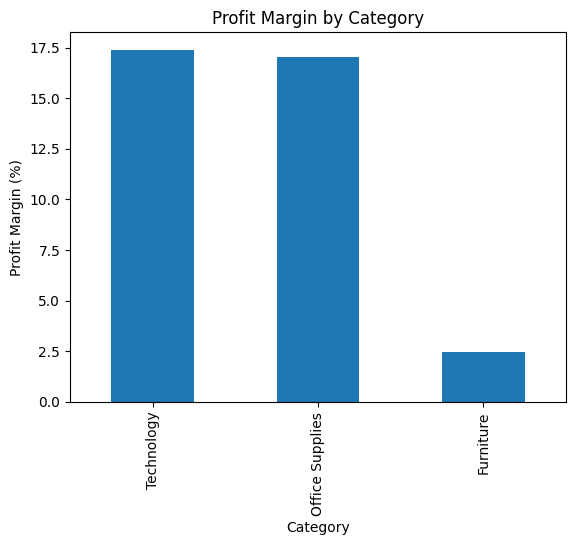

In [57]:
category_final.plot(
    kind="bar",
    y="Profit_Margin_%",
    title="Profit Margin by Category",
    ylabel="Profit Margin (%)",
    xlabel="Category",
    legend=False
)

<Axes: title={'center': 'Profit Margin by Discount'}, xlabel='Discount', ylabel='Profit Margin (%)'>

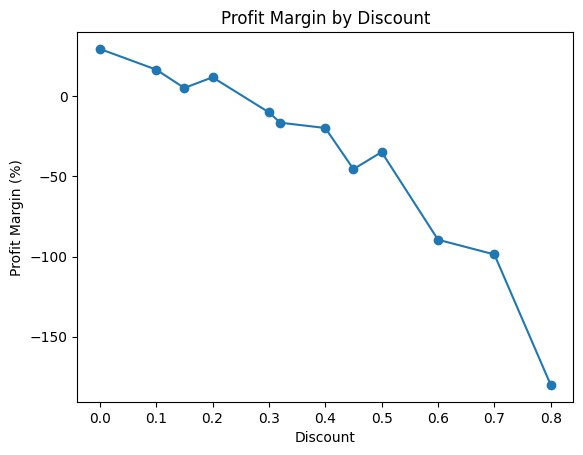

In [58]:
discount_analysis.plot(
    kind="line",
    y="Profit_Margin_%",
    marker="o",
    title="Profit Margin by Discount",
    ylabel="Profit Margin (%)",
    xlabel="Discount",
    legend=False
)